#Proyecto Pregrado Aprendizaje Automático

Miguel Ciavato C.I. 30.541.929

Jhonatan Homsany C.I. 30.182.893

El presente documento describe la implementación de un modelo de aprendizaje supervisado con el objetivo de predecir el ganador en una partida a nivel competitivo del videojuego Super Smash Bros Ultimate.

##Entendimiento del contexto.

Super Smash Bros Ultimate es un videojuego de lucha desarrollado por Nintendo que destaca principalmente por ser el crossover más grande en la historia de la industria. Múltiples personajes de videojuegos que han marcado un hito en el medio se encuentran disponibles en este videojuego para que los jugadores puedan utilizarlo. Actualmente, el videojuego cuenta con $82$ personajes jugables sumado a tres tipos disponibles de luchadores Mii.

El videojuego destaca por la manera en la que permite que se adapten todo tipo de jugadores. Una persona común puede jugar al videojuego sin problemas simplemente entendiendo sus controles y al mismo tiempo el juego presenta una gran cantidad de mecánicas adicionales que le brindan valor competitivo al videojuego. Dominar estas mecánicas requieren de bastante práctica y habilidad, por lo que suelen ser vistas más que nada en los torneos oficiales.

A pesar de contar con $103$ escenarios para los combates, los torneos competitivos suelen reducir este conjunto al que se muestra en la siguiente imagen:

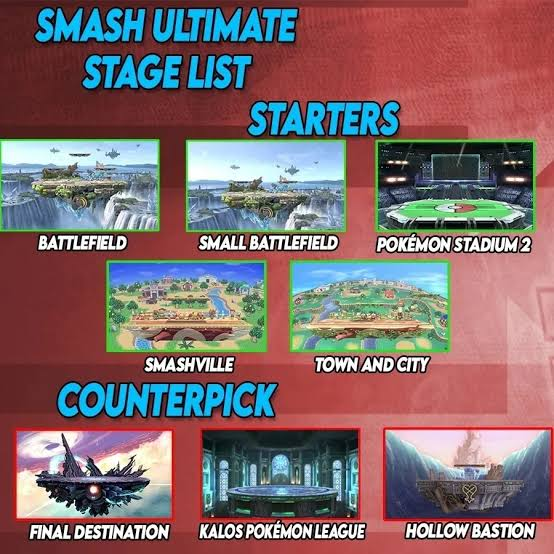


esto con el objetivo de disputar los combates en escenarios que no presenten variables (o lo que en el juego se conoce como 'hazards') que puedan influir en la partida. Estos escenarios permiten que los jugadores aprovechen al máximo sus habiliades en el enfrentamiento sin tener elementos externos que puedan condicionar su victoria. En la imagen, notamos que algunos escenarios son considerados startes mientras que otros son considerados counterpick, veamos esto con más detalle mientras entendemos las reglas de la competición.

###Reglas.

En los torneos de Super Smash Bros Ultimate, todos los jugadores comienzan en lo que se considera "la llave de los ganadores". En esta llave, se arman los enfrentamientos donde el ganador se determina a partir de quien gane más partidas en un set de $3$, $5$, o $7$ partidas dependiendo de la competición (generalmente se escoge un set de $3$ debido a la gran cantidad de participantes). Cuando un jugador pierde un set estando en la llave de ganadores, es enviado a "la llave de los perdedores". Si vuelve a perder en dicha llave, entonces el jugador es descalificado.

En la llave de los perdedores, los jugadores siguen avanzando con las mismas reglas hasta llegar a la final. En la final, se enfrenta el mejor jugador en la llave de ganadores contra el mejor jugador en la llave de perdedores. La particularidad de esta final es que, el jugador que proviene de la llave de perdedores debe ganarle dos sets al que proviene de la llave de ganadores. Podríamos entender esto como que primero debe enviarlo a la llave de perdedores ganandole el primer set, y luego debe ganarle de nuevo para así descalificarlo y conseguir la victoria.

Con respecto a los escenarios, estos se dividen de acuerdo al número de la partida actual. Por ejemplo, en la primera partida, están disponibles únicamente los escenarios en la sección de "starters". Acá, un jugador elimina de la lista un escenario y luego el otro elimina dos. En este punto, estarán disponibles tres escenarios que pueden ser seleccionados por el jugador que realizó el primer bloqueo. Tras la primera partida, están disponibles los escenarios en "counterpick" y se repite el procedimiento de eliminación y selección de la primera partida.

No profundizaremos en las reglas asociadas a la selección de personajes dado que no es relevante para el estudio en cuestión o para el entrenamiento de nuestro modelo.

##Carga de datos.

Como se menciona en el PDF que acompaña a esta implementación, los datos han sido extraídos de la web start.gg a través de su API accesible desde GraphQL.

Antes de poder ejecutar los códigos desarrollados a continuación, es importante que el usuario haya cargado en su respectivo entorno el archivo ssbu_matchups.csv que acompaña a este documento.

Al ser un videojuego competitivo, Super Smash Bros Ultimate es un videojuego que recibe muchas actualizaciones a lo largo de los años, en especial, en los primeros años del videojuego. En el año 2022, cuatro años después de su lanzamiento, Nintendo anunció que el juego no recibiría más actualizaciones ni cambios de balance. Por esta razón, los datos extraídos describen torneos realizados luego de esta actualización para tener resultados más acordes al estado actual del videojuego.

Los datos a utilizar se tienen disponibles en un .csv adjuntos con el proyecto y que será cargado en esta implementación en Google Colab. El CSV contiene los campos `set_id`,`game_id`,`game_order`,`stage_name`,`p1_name`,`p1_char_name`,`p2_name`,`p2_char_name`,`p1_won`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ssbu_matchups.csv')

##Exploración de los datos.

En esta sección, evaluaremos el conjunto de datos para obtener diferentes estadísticas referentes a los personajes más utilizados, los mejores y peores personajes, los escenarios más seleccionados y los mejores jugadores del mundo con su respectivo personaje principal. El objetivo de esto es evaluar la calidad de los datos contrastandolo con el conocimiento general que se tiene referente al juego, especialmente con respecto a la popularidad de los personajes y el top tier actual del juego.

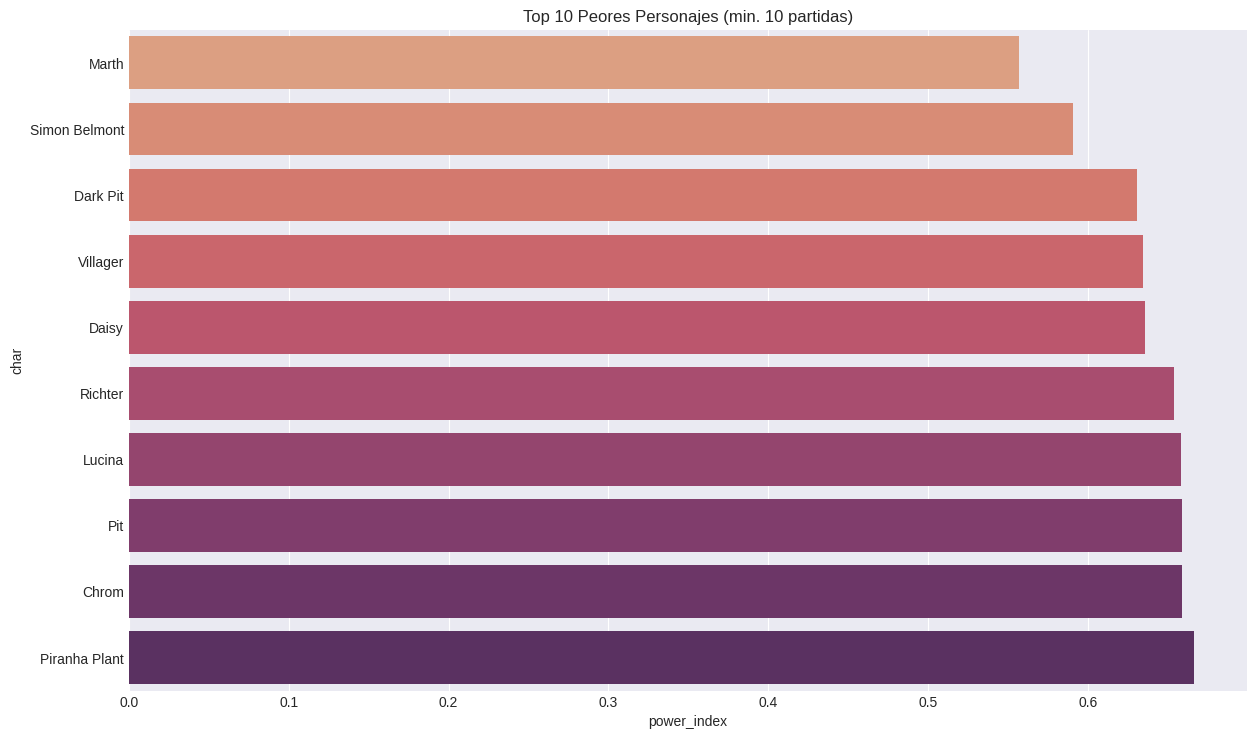

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocesamiento de Escenarios ---
df['stage_name'] = df['stage_name'].str.replace(r'Pokémon Stadiu.*', 'Pokémon Stadium 2', regex=True)
df['stage_name'] = df['stage_name'].str.replace(r'Battlefield.*', 'Battlefield', regex=True)
df['stage_name'] = df['stage_name'].str.replace(r'Final Destinatio.*', 'Final Destination', regex=True)

# --- Cálculo de Fuerza de Jugadores (Ajuste Bayesiano) ---
p1_j = df[['p1_name', 'p1_won']].rename(columns={'p1_name': 'player', 'p1_won': 'won'})
p2_j = df[['p2_name', 'p1_won']].rename(columns={'p2_name': 'player', 'p1_won': 'won'})
p2_j['won'] = p2_j['won'].apply(lambda x: 1 if x == 0 else 0)
all_players = pd.concat([p1_j, p2_j])

m_player = 10
C = all_players['won'].mean()
player_stats = all_players.groupby('player')['won'].agg(['count', 'sum'])
player_stats['win_rate_adj'] = (player_stats['sum'] + m_player * C) / (player_stats['count'] + m_player)
player_power = player_stats['win_rate_adj'].to_dict()

# --- Cálculo de Power Index por Personaje ---
df['p2_strength'] = df['p2_name'].map(player_power).fillna(0.5)
df['p1_strength'] = df['p1_name'].map(player_power).fillna(0.5)

df['p1_points'] = df.apply(lambda x: x['p2_strength'] if x['p1_won'] == 1 else 0, axis=1)
df['p2_points'] = df.apply(lambda x: x['p1_strength'] if x['p1_won'] == 0 else 0, axis=1)

p1_c = df[['p1_char_name', 'p1_points', 'p1_won']].rename(columns={'p1_char_name': 'char', 'p1_points': 'pts', 'p1_won': 'win'})
p2_c = df[['p2_char_name', 'p2_points', 'p1_won']].rename(columns={'p2_char_name': 'char', 'p2_points': 'pts', 'p1_won': 'win'})
p2_c['win'] = p2_c['win'].apply(lambda x: 1 if x == 0 else 0)

char_final = pd.concat([p1_c, p2_c]).groupby('char').agg(partidas=('win', 'count'), puntos_totales=('pts', 'sum'))
char_final['power_index'] = (char_final['puntos_totales'] / char_final['partidas']) * np.log10(char_final['partidas'] + 1)

# --- Visualización ---
plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(24, 28))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 2])

# Gráficos de barra superiores (usando el Power Index original para consistencia estadística)
top_power = char_final.sort_values('power_index', ascending=False).head(10)
worst_power = char_final[char_final['partidas'] >= 10].sort_values('power_index', ascending=True).head(10)

ax1 = fig.add_subplot(gs[0, 0])
sns.barplot(x=top_power['power_index'], y=top_power.index, palette='viridis', hue=top_power.index, ax=ax1, legend=False)
ax1.set_title('Top 10 Personajes')

ax2 = fig.add_subplot(gs[0, 1])
sns.barplot(x=worst_power['power_index'], y=worst_power.index, palette='flare', hue=worst_power.index, ax=ax2, legend=False)
ax2.set_title('Top 10 Peores Personajes (min. 10 partidas)')

ax4 = fig.add_subplot(gs[1, 0])
top_stages = df[df['stage_name'] != 'Unknown']['stage_name'].value_counts().head(7)
top_stages.plot(kind='pie', autopct='%1.1f%%', ax=ax4, colors=sns.color_palette('pastel'))
ax4.set_title('Escenarios más frecuentes')

plt.tight_layout()
plt.savefig('ssbu_matchup_analysis.png') # Guardamos el archivo

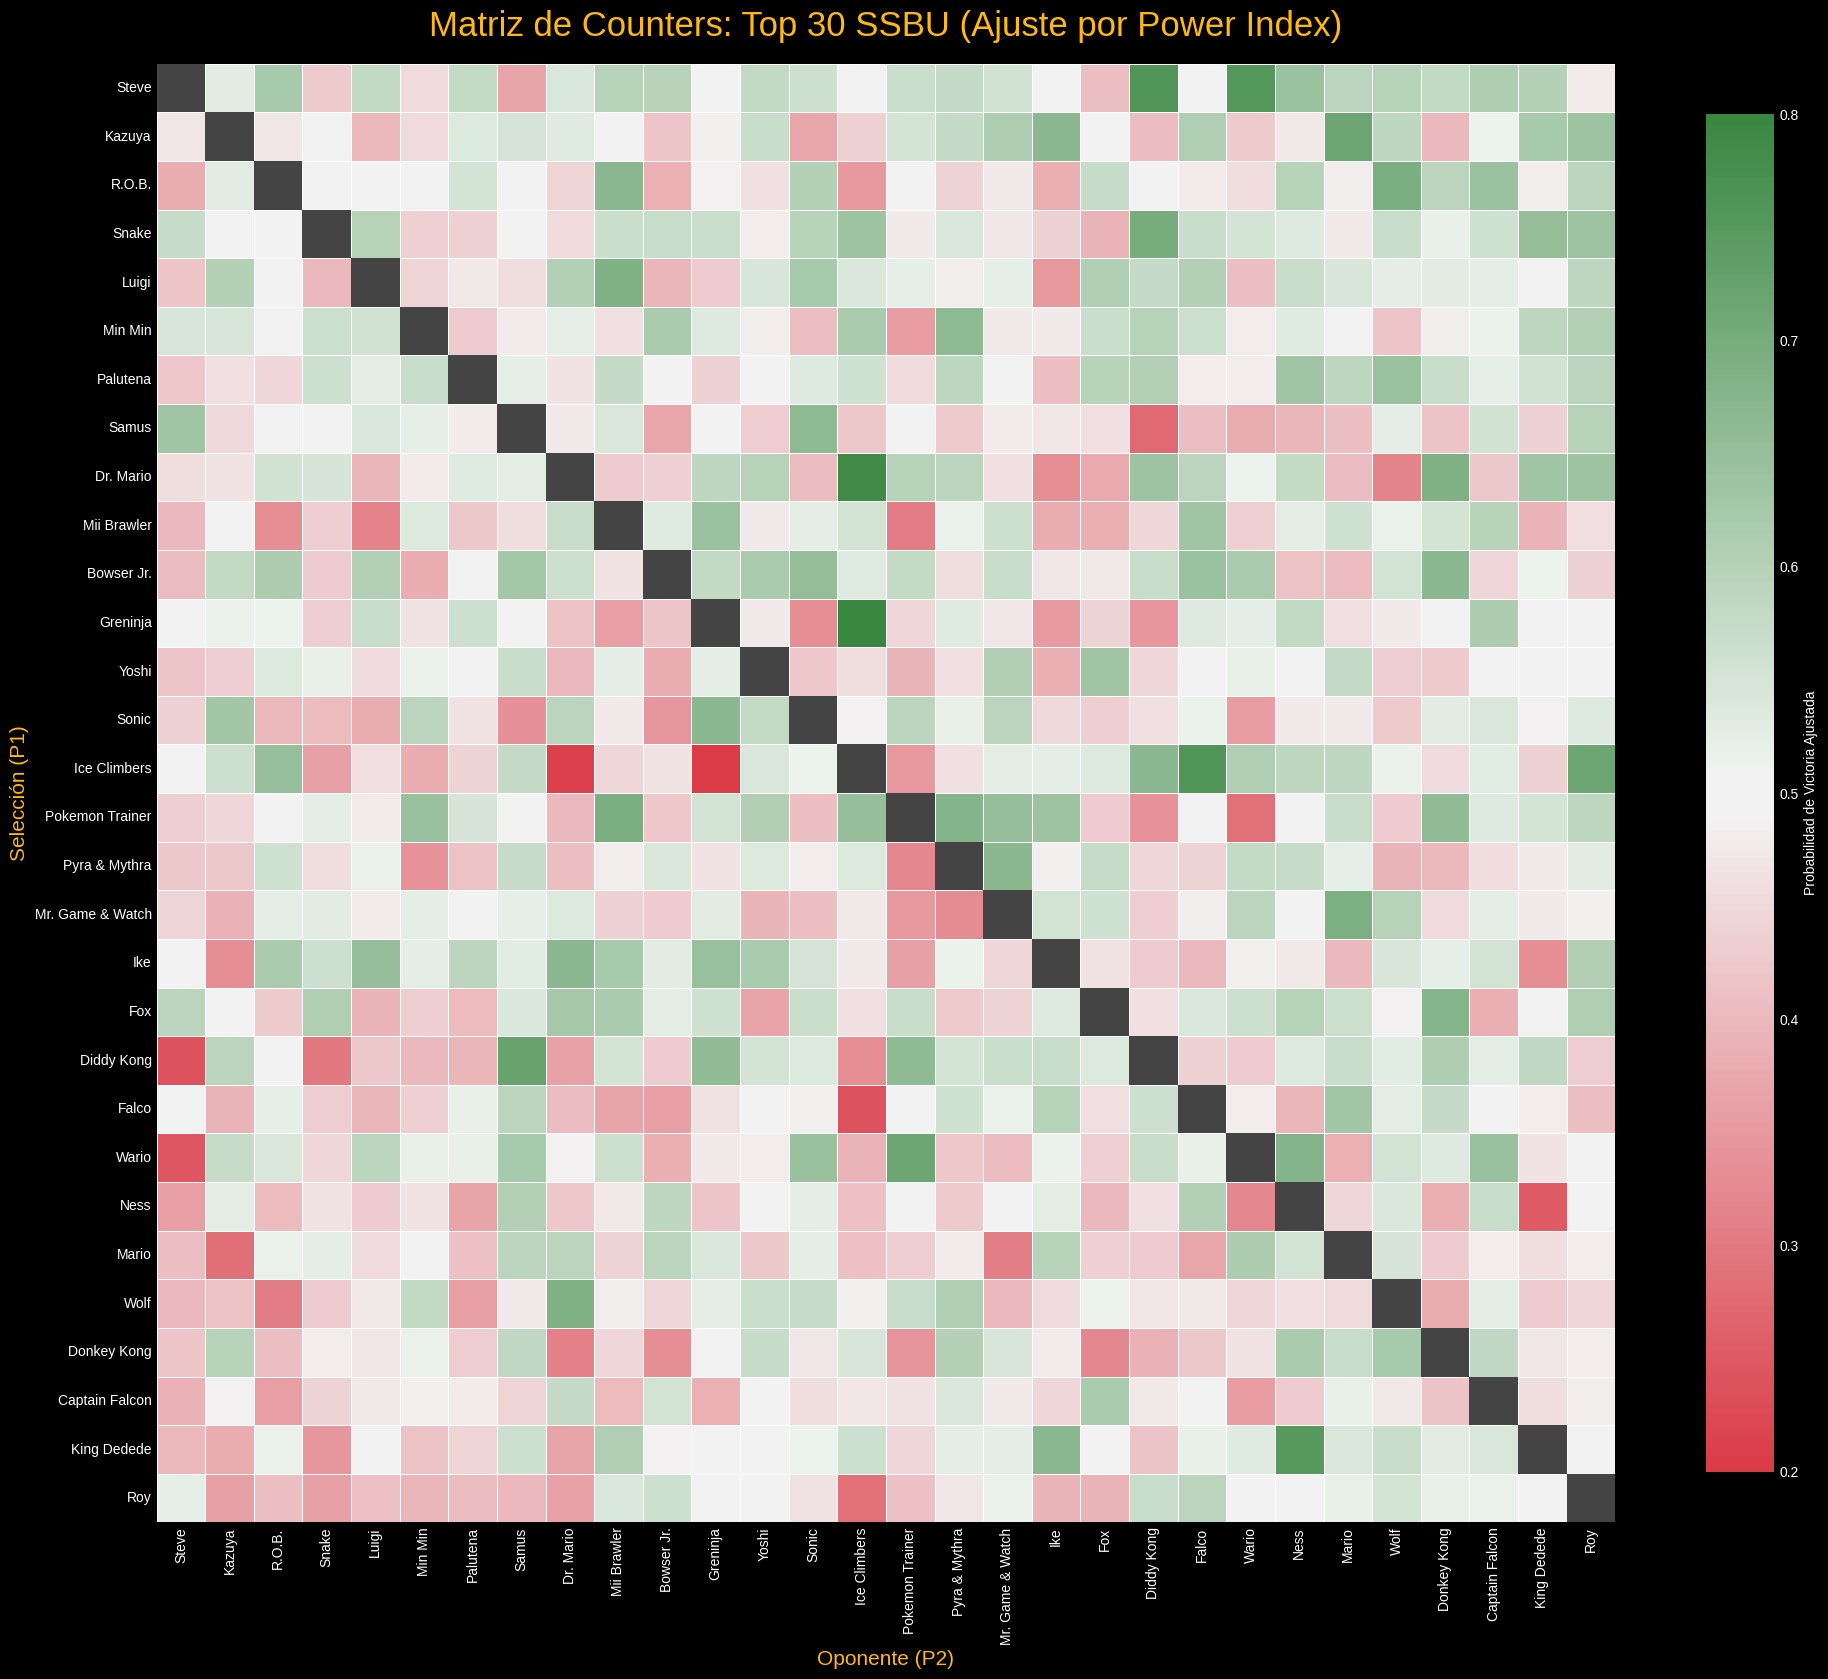

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# IDENTIFICAR EL TOP 30
p1_j = df[['p1_name', 'p1_won']].rename(columns={'p1_name': 'player', 'p1_won': 'won'})
p2_j = df[['p2_name', 'p1_won']].rename(columns={'p2_name': 'player', 'p1_won': 'won'})
p2_j['won'] = p2_j['won'].apply(lambda x: 1 if x == 0 else 0)
all_players = pd.concat([p1_j, p2_j])

m_player = 10
C_global = all_players['won'].mean()
player_stats = all_players.groupby('player')['won'].agg(['count', 'sum'])
player_stats['win_rate_adj'] = (player_stats['sum'] + m_player * C_global) / (player_stats['count'] + m_player)
player_power_dict = player_stats['win_rate_adj'].to_dict()

df['p2_strength'] = df['p2_name'].map(player_power_dict).fillna(0.5)
df['p1_strength'] = df['p1_name'].map(player_power_dict).fillna(0.5)
df['p1_points'] = df.apply(lambda x: x['p2_strength'] if x['p1_won'] == 1 else 0, axis=1)
df['p2_points'] = df.apply(lambda x: x['p1_strength'] if x['p1_won'] == 0 else 0, axis=1)

p1_c = df[['p1_char_name', 'p1_points', 'p1_won']].rename(columns={'p1_char_name': 'char', 'p1_points': 'pts', 'p1_won': 'win'})
p2_c = df[['p2_char_name', 'p2_points', 'p1_won']].rename(columns={'p2_char_name': 'char', 'p2_points': 'pts', 'p1_won': 'win'})
p2_c['win'] = p2_c['win'].apply(lambda x: 1 if x == 0 else 0)

char_stats = pd.concat([p1_c, p2_c]).groupby('char').agg(partidas=('win', 'count'), puntos_totales=('pts', 'sum'))
char_stats['power_index'] = (char_stats['puntos_totales'] / char_stats['partidas']) * np.log10(char_stats['partidas'] + 1)

# Seleccionamos los 30 personajes con mayor Power Index
top_30_chars = char_stats.sort_values('power_index', ascending=False).head(30).index.tolist()

# Filtramos el dataframe para trabajar solo con el Top 30
df_top = df[(df['p1_char_name'].isin(top_30_chars)) & (df['p2_char_name'].isin(top_30_chars))].copy()

# Agrupamos por pareja para obtener victorias y total de encuentros
pairwise = df_top.groupby(['p1_char_name', 'p2_char_name']).agg(
    wins=('p1_won', 'sum'),
    total=('p1_won', 'count')
).reset_index()

# Creamos matrices cuadradas de victorias y totales
wins_matrix = pairwise.pivot(index='p1_char_name', columns='p2_char_name', values='wins').reindex(index=top_30_chars, columns=top_30_chars).fillna(0)
total_matrix = pairwise.pivot(index='p1_char_name', columns='p2_char_name', values='total').reindex(index=top_30_chars, columns=top_30_chars).fillna(0)

# SIMETRÍA Y LÓGICA DE POWER INDEX 
m_pairwise = 2
sym_wins = wins_matrix + (total_matrix.T - wins_matrix.T)
sym_total = total_matrix + total_matrix.T

# Esta es la probabilidad simétrica ajustada por volumen
matchup_matrix = (sym_wins + m_pairwise * 0.5) / (sym_total + m_pairwise)

# 4. VISUALIZACIÓN
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(20, 18))

# Máscara para la diagonal (se pintará de gris manualmente)
diag_mask = np.eye(len(top_30_chars), dtype=bool)

# Mapa de colores: Rojo (Desventaja) -> Gris (Even) -> Verde (Ventaja)
cmap = sns.diverging_palette(10, 130, sep=10, n=20, as_cmap=True)

sns.heatmap(
    matchup_matrix,
    mask=diag_mask,
    cmap=cmap,
    center=0.5,
    square=True,
    linewidths=.5,
    cbar_kws={"label": "Probabilidad de Victoria Ajustada", "shrink": .8},
    ax=ax
)

# Pintar la diagonal de gris
for i in range(len(top_30_chars)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color='#444444', lw=0))

plt.title('Matriz de Counters: Top 30 SSBU (Ajuste por Power Index)', fontsize=25, pad=20, color='#FDB813')
plt.xlabel('Oponente (P2)', fontsize=15, color='#FDB813')
plt.ylabel('Selección (P1)', fontsize=15, color='#FDB813')

plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

Para determinar la viabilidad competitiva de un personaje (Tier List), se descartó el uso de la proporción de victorias simple debido al sesgo de popularidad.

Por un lado, personajes de nicho como Ice Climbers presentan un Win Rate inflado; esto ocurre porque son seleccionados casi exclusivamente por especialistas (mains) que poseen un dominio avanzado del personaje, obteniendo victorias consistentes en rondas iniciales antes de ser eliminados. Por otro lado, personajes de alto rendimiento (Top Tiers) como Joker gozan de una popularidad masiva, lo que incentiva a jugadores de menor nivel de habilidad a utilizarlos, acumulando derrotas que no reflejan el potencial real del personaje.

En consecuencia, la métrica de 'calidad' se ha normalizado mediante un power index que pondera la capacidad del personaje para mantener un rendimiento sólido a través de miles de partidas y la instancia del torneo y el nivel del oponente vencido, otorgando mayor peso a quienes logran avanzar hacia las fases finales del cuadro competitivo.

Analizando los resultados, tenemos que estos reflejan en gran medida la realidad. Personajes como Steve, Kazuya, Snake, R.O.B y Luigi se sitúan entre los mejores personajes del juego, tal y como ocurre en el top tier de la comunidad oficial de Super Smash Bros.

Por otro lado, el análisis de los datos reveló cierto ruido sobretodo con los escenarios utilizados para las partidas. Una cantidad considerable de partidas indican que el escenario usado fue "unknown", seguramente por un error al registrar la partida en la página de Start.gg.

Finalmente, el mapa de calor revela a su vez resultados bastante fidedignos con la realidad con respecto al dominio que tienen los personajes sobre el resto del roster en relación al balance del juego.

A continuación, se presenta el tierlist oficial del juego:

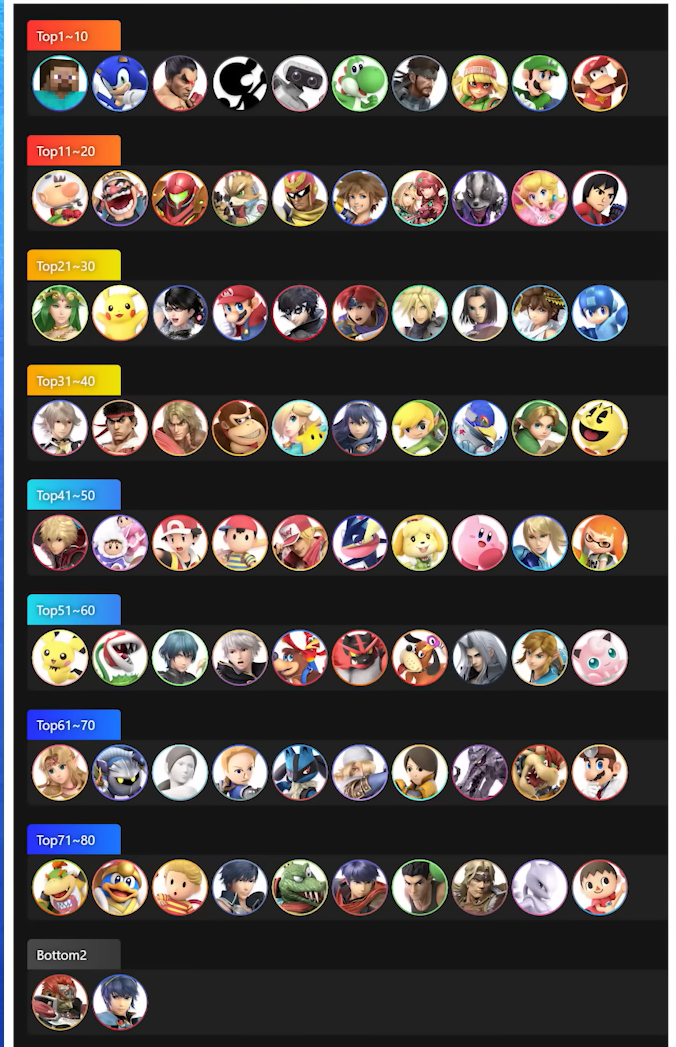

##Preprocesamiento de los datos.

Para el procesamiento de datos, inicialmente debemos realizar una transformación dado que el modelo no es capaz de procesar entradas de texto. Bajo esta premisa, estaremos utilizando la técnica del label encoding para transformar los datos.

Adicionalmente, incluiremos una característica adicional que llamaremos Power Index donde se considerará a los jugadores enfrentados y los personajes que suelen utilizar. De esta manera, podremos darle más peso al rendimiento de los jugadores en lugar de basarnos en la tasa de victorias.

Como es habitual, haremos una división del conjunto de datos del $70\%$ para el entrenamiento y el $30\%$ para la validación.

In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

char_power_map = char_final['power_index'].to_dict()

player_power_dict = player_power

df_clean = df[df['stage_name'] != 'Unknown'].copy()

df_clean['p1_power'] = df_clean['p1_char_name'].map(char_power_map)
df_clean['p2_power'] = df_clean['p2_char_name'].map(char_power_map)
df_clean['p1_player_wr'] = df_clean['p1_name'].map(player_power_dict).fillna(0.5)
df_clean['p2_player_wr'] = df_clean['p2_name'].map(player_power_dict).fillna(0.5)

le_char = LabelEncoder()
le_stage = LabelEncoder()

all_chars = pd.concat([df['p1_char_name'], df['p2_char_name']]).unique()
le_char.fit(all_chars)
le_stage.fit(df_clean['stage_name'].unique())

df_clean['p1_char_int'] = le_char.transform(df_clean['p1_char_name'])
df_clean['p2_char_int'] = le_char.transform(df_clean['p2_char_name'])
df_clean['stage_int'] = le_stage.transform(df_clean['stage_name'])

features = ['p1_char_int', 'p2_char_int', 'stage_int', 'p1_power', 'p2_power', 'p1_player_wr', 'p2_player_wr']
X = df_clean[features]
y = df_clean['p1_won']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset listo para entrenamiento: {X_train.shape}")

Dataset listo para entrenamiento: (30230, 7)


##Entrenamiento

Para las predicciones, estaremos utilizando un modelo basado en regresión logística para así calcular la probabilidad de que un jugador gane dadas unas condiciones iniciales. Estaríamos realizando una predicción del ganador apenas comenzar la partida.

In [5]:
import matplotlib.pyplot as plt

plt.style.use('default')

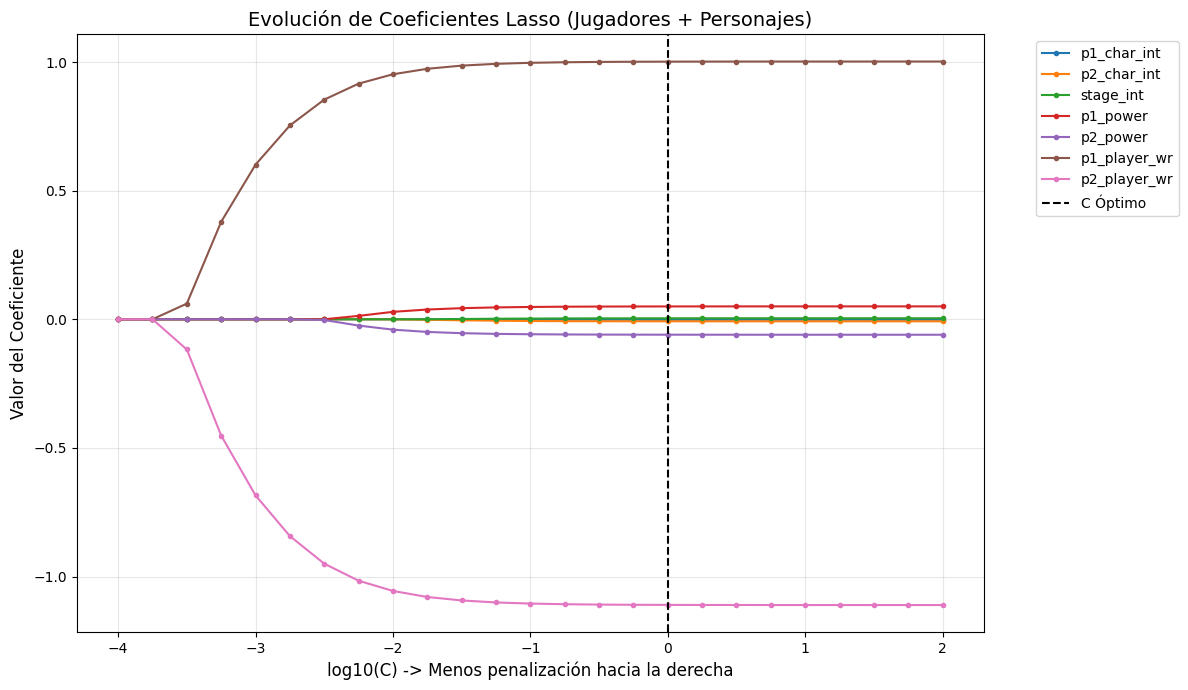


Impacto final de cada variable:
       Variable   Impacto
5  p1_player_wr  1.001442
3      p1_power  0.049882
2     stage_int  0.003753
0   p1_char_int -0.001698
1   p2_char_int -0.007825
4      p2_power -0.060052
6  p2_player_wr -1.110214


In [6]:
from sklearn.linear_model import LogisticRegressionCV

Cs_range = np.logspace(-4, 2, 25)
lasso_model = LogisticRegressionCV(
    Cs=Cs_range,
    cv=5,
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',
    random_state=42
)
lasso_model.fit(X_train_scaled, y_train)

plt.figure(figsize=(12, 7))
paths = np.mean(lasso_model.coefs_paths_[1], axis=0)

for i, feature in enumerate(features):
    plt.plot(np.log10(lasso_model.Cs_), paths[:, i], label=feature, marker='o', markersize=3)

plt.axvline(np.log10(lasso_model.C_[0]), color='black', linestyle='--', label='C Óptimo')
plt.title('Evolución de Coeficientes Lasso (Jugadores + Personajes)', fontsize=14)
plt.xlabel('log10(C) -> Menos penalización hacia la derecha', fontsize=12)
plt.ylabel('Valor del Coeficiente', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

coef_df = pd.DataFrame({'Variable': features, 'Impacto': lasso_model.coef_[0]})
print("\nImpacto final de cada variable:")
print(coef_df.sort_values(by='Impacto', ascending=False))

El impacto de las variables tras aplicar Lasso nos indica que la mejor manera que tenemos para predecir al ganador de una partida es en base a su consistencia, seguida de la viabilidad técnica del personaje. Seguido de esto, tenemos el impacto del escenario que si bien afecta al personaje, los jugadores más habilidosos son capaces de adaptarse a este tipo de situaciones para lograr la victoria.

##Evaluación.

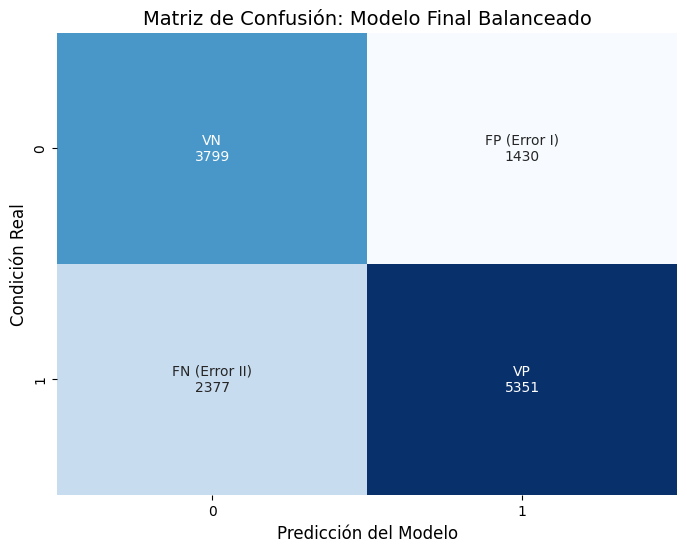


       REPORTE DE MÉTRICAS FINALES
Precisión Balanceada: 70.95%
F1 Score:             0.7376
Sensibilidad (TRP):   0.6924
Especificidad (TRN):  0.7265
Precisión (VPP):      0.7891


In [7]:
from sklearn.metrics import confusion_matrix, f1_score, classification_report

y_pred = lasso_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
VN, FP, FN, VP = cm.ravel()

P, N = VP + FN, VN + FP
TRP = VP / P if P > 0 else 0
TRN = VN / N if N > 0 else 0
VPP = VP / (VP + FP) if (VP + FP) > 0 else 0
F1 = f1_score(y_test, y_pred)
ACC_BAL = (TRP + TRN) / 2

plt.figure(figsize=(8, 6))
labels = np.array([[f"VN\n{VN}", f"FP (Error I)\n{FP}"], [f"FN (Error II)\n{FN}", f"VP\n{VP}"]])
sns.heatmap(cm, annot=labels, fmt="", cmap='Blues', cbar=False)
plt.title('Matriz de Confusión: Modelo Final Balanceado', fontsize=14)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Condición Real', fontsize=12)
plt.show()

print("\n" + "="*45)
print("       REPORTE DE MÉTRICAS FINALES")
print("="*45)
print(f"Precisión Balanceada: {ACC_BAL:.2%}")
print(f"F1 Score:             {F1:.4f}")
print(f"Sensibilidad (TRP):   {TRP:.4f}")
print(f"Especificidad (TRN):  {TRN:.4f}")
print(f"Precisión (VPP):      {VPP:.4f}")
print("="*45)

A pesar de que la precisión del modelo es del $70,95\%$, tenemos que este valor sigue siendo aceptable dado que es una consecuencia inherente de las variables que ocurren durante una partida que es imposible predecir de antemano. En una partida de Smash en ocasiones ocurren escenarios en los que un jugador pierde una vida de manera accidental, el control comienza a fallar y comienza a sufrir de input lag, o simplemente los comandos que realiza no responden de manera correcta dentro del juego. Esto, agrega ruido a nuestros datos y hace que la precisión del modelo baje considerablemente.

##Comparación con otros modelos.

En esta sección, se entrenarán otros modelos utilizando otras técnicas de aprendizaje automático con el objetivo de realizar comparaciones y poder descubrir que modelo arroja mejores resultados. Los modelos que estaremos entrenando son los árboles de decisión y máquinas de soporte vectorial. Tras probar los modelos, se computarán las mismas estadísticas que para regresión logística y se contrastarán para elegir el modelo con mejores resultados.

###Árboles de decisión.

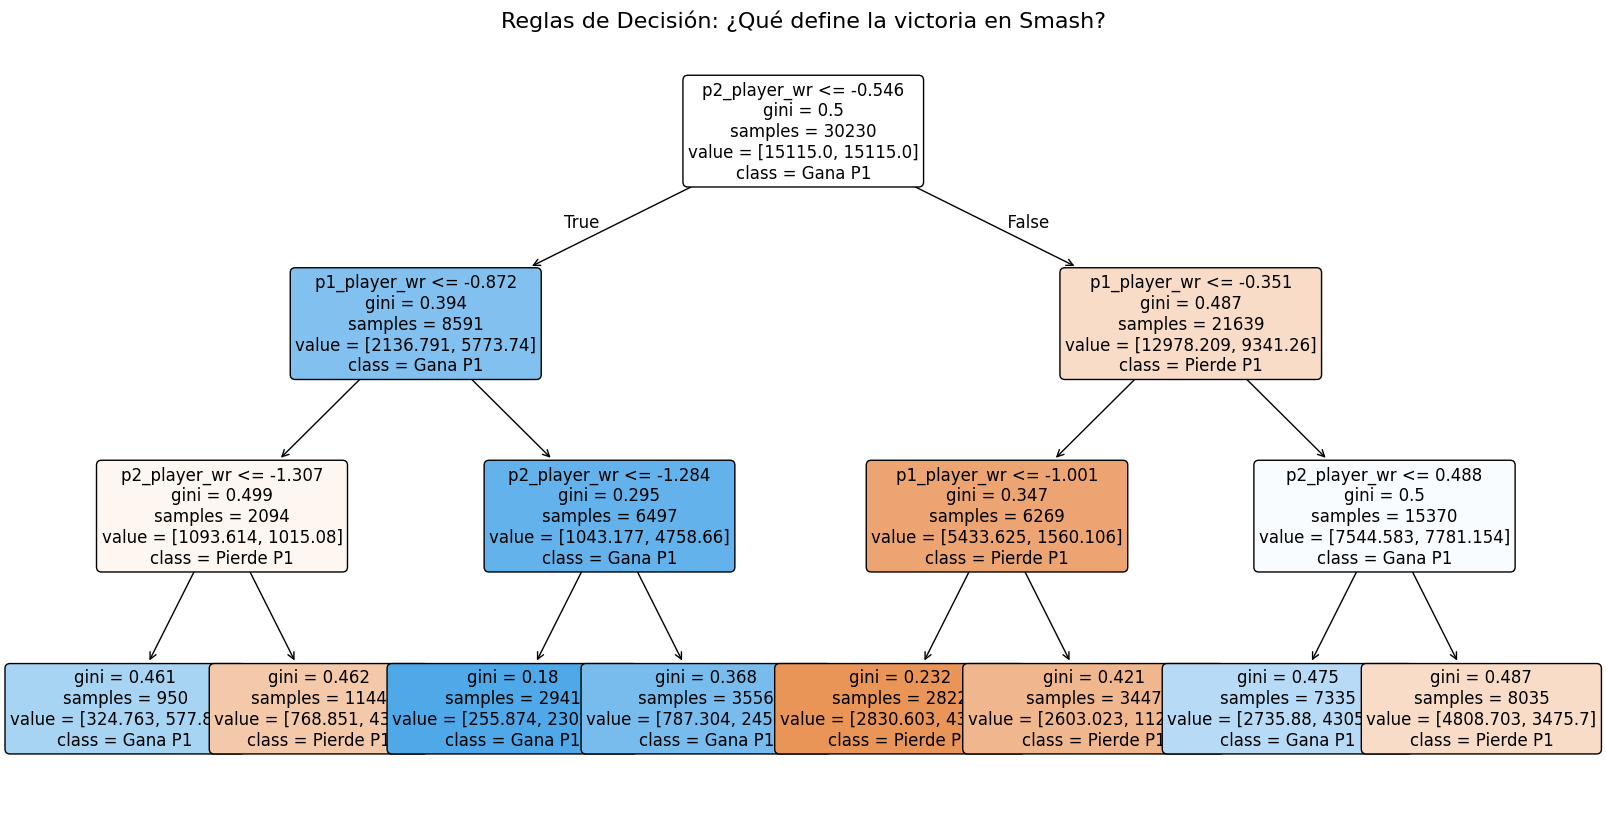

In [8]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_model = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
tree_model.fit(X_train_scaled, y_train)

y_pred_tree = tree_model.predict(X_test_scaled)
f1_tree = f1_score(y_test, y_pred_tree)
cm_tree = confusion_matrix(y_test, y_pred_tree)
acc_bal_tree = ( (cm_tree[0,0]/cm_tree[0,:].sum()) + (cm_tree[1,1]/cm_tree[1,:].sum()) ) / 2

plt.figure(figsize=(20,10))
plot_tree(tree_model, feature_names=features, class_names=['Pierde P1', 'Gana P1'], filled=True, rounded=True, fontsize=12)
plt.title("Reglas de Decisión: ¿Qué define la victoria en Smash?", fontsize=16)
plt.show()

###Máquinas de soporte vectorial.

In [9]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=42,
    cache_size=700,
    tol=1e-2,
    max_iter=5000
)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
f1_svm = f1_score(y_test, y_pred_svm)
cm_svm = confusion_matrix(y_test, y_pred_svm)
acc_bal_svm = ( (cm_svm[0,0]/cm_svm[0,:].sum()) + (cm_svm[1,1]/cm_svm[1,:].sum()) ) / 2

print(f"SVM finalizado. F1-Score: {f1_svm:.4f} | Precisión Bal: {acc_bal_svm:.2%}")

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVM finalizado. F1-Score: 0.6830 | Precisión Bal: 57.22%


###Comparación estadística.

In [10]:
metrics = {
    'Modelo': ['Regresión Logística', 'SVM', 'Árbol de Decisión'],
    'Tipo': ['Supervisado', 'Supervisado', 'Supervisado'],
    'F1-Score': [round(F1, 4), round(f1_svm, 4), round(f1_tree, 4)],
    'Precisión Balanceada': [f"{ACC_BAL:.2%}", f"{acc_bal_svm:.2%}", f"{acc_bal_tree:.2%}"]
}

df_comparativo = pd.DataFrame(metrics)

print("\n" + "="*75)
print("          ESTUDIO COMPARATIVO FINAL: PREDICCIÓN SMASH ULTIMATE")
print("="*75)
print(df_comparativo.sort_values(by='F1-Score', ascending=False).to_string(index=False))
print("="*75)


          ESTUDIO COMPARATIVO FINAL: PREDICCIÓN SMASH ULTIMATE
             Modelo        Tipo  F1-Score Precisión Balanceada
Regresión Logística Supervisado    0.7376               70.95%
  Árbol de Decisión Supervisado    0.7012               68.47%
                SVM Supervisado    0.6830               57.22%


##Conclusiones.

El análisis comparativo final confirma que la regresión logística es el modelo más eficaz para predecir resultados en Smash Ultimate, logrando un equilibrio superior entre sensibilidad y especificidad con una precisión balanceada del $70.95\%$. Por otro lado, el SVM muestra un rendimiento inesperadamente bajo (57.22%), lo que sugiere que intentar forzar fronteras de decisión complejas en un dataset con tanto "ruido" humano y variables categóricas resulta en un sobreajuste o en una incapacidad de generalizar frente a la estructura más clara y directa del árbol de decisión y la regresión logística. En conclusión, para este entorno competitivo, los modelos lineales y basados en reglas ofrecen una mayor confiabilidad para capturar la ventaja real entre jugadores y personajes.